# Maximum likelihood and sufficient statistics

What maximum-likelihood estimation (MLE) actually optimizes, why for exponential-family models a handful of sufficient statistics carry all the information the data have about the parameters (and why that is exactly what mixle's accumulators compute), and the two large-sample guarantees that make the MLE trustworthy: consistency and asymptotic normality.


## Setup and notation

A parametric statistical model is a family of probability densities (or mass functions)
$\mathcal P = \{\, p(\cdot\mid\theta) : \theta\in\Theta \,\}$ on a sample space $\mathcal X$, indexed by a
parameter $\theta$ in an open set $\Theta\subseteq\mathbb R^d$. We observe data $x_1,\dots,x_n$ assumed
independent and identically distributed (iid) from $p(\cdot\mid\theta_0)$ for some unknown true value
$\theta_0$. The estimation problem is to recover $\theta_0$ from the data, and to quantify how much the
data can possibly say about it.

Two questions organize the whole subject. First, what function of the data should we compute (and is
there a smallest such function that loses nothing)? That is the theory of sufficiency. Second, how good
can any estimator be, and does maximum likelihood achieve it? That is the theory of information and
efficiency. The rest of this notebook answers both, with the Gaussian as the running example, and then
shows where the guarantees break.

## The score and Fisher information

Write the log-likelihood of a single observation as $\ell(\theta; x) = \log p(x\mid\theta)$ and of the
sample as $\ell_n(\theta) = \sum_{i=1}^n \ell(\theta; x_i)$. The maximum-likelihood estimator (MLE) is
any maximizer
$$\hat\theta_n \in \arg\max_{\theta\in\Theta} \ell_n(\theta).$$

Definition (score). The score is the gradient of the log-likelihood in the parameter,
$s(\theta; x) = \nabla_\theta \ell(\theta; x)$. At an interior maximum the sample score vanishes:
$\sum_i s(\hat\theta_n; x_i) = 0$. These are the likelihood equations.

We assume throughout the standard regularity conditions: the support of $p(\cdot\mid\theta)$ does not
depend on $\theta$; $\theta\mapsto p(x\mid\theta)$ is twice continuously differentiable; and
differentiation under the integral sign is permitted (dominated convergence). The final counterexample
shows what happens when the support condition fails.

Lemma (the score is mean zero). Under the regularity conditions, $\mathbb E_\theta[s(\theta; X)] = 0$.

Proof. Densities integrate to one: $\int p(x\mid\theta)\,dx = 1$. Differentiate both sides in $\theta$
and exchange derivative and integral:
$$0 = \nabla_\theta \int p(x\mid\theta)\,dx = \int \nabla_\theta p(x\mid\theta)\,dx
   = \int \frac{\nabla_\theta p(x\mid\theta)}{p(x\mid\theta)}\, p(x\mid\theta)\,dx
   = \int s(\theta;x)\, p(x\mid\theta)\,dx = \mathbb E_\theta[s(\theta;X)],$$
using $\nabla_\theta \log p = (\nabla_\theta p)/p$. $\quad\blacksquare$

Definition (Fisher information). The Fisher information of one observation is the covariance of the
score, $\mathcal I(\theta) = \mathbb E_\theta\!\big[\, s(\theta;X)\, s(\theta;X)^\top \,\big]$ (the mean
being zero). It measures how sharply the log-likelihood bends, that is, how much a single observation
tells you about $\theta$.

Theorem (information equality). Under the regularity conditions,
$$\mathcal I(\theta) = -\,\mathbb E_\theta\!\big[\, \nabla^2_\theta \ell(\theta; X) \,\big].$$

Proof. Differentiate the identity $\int s(\theta;x)\,p(x\mid\theta)\,dx = 0$ once more in $\theta$:
$$0 = \int \big[\nabla_\theta s\big] p\,dx + \int s\,(\nabla_\theta p)^\top dx
    = \mathbb E_\theta[\nabla^2_\theta \ell] + \mathbb E_\theta[s\, s^\top],$$
since $\nabla_\theta p = p\, s^\top$ and $\nabla_\theta s = \nabla^2_\theta \ell$. Rearranging gives the
claim. $\quad\blacksquare$

For $n$ iid observations the scores add and are independent, so the sample information is
$n\,\mathcal I(\theta)$: information accumulates linearly in the sample size.

## Sufficiency: compressing the data without losing information

Definition (sufficiency). A statistic $T = T(X_1,\dots,X_n)$ is sufficient for $\theta$ if the
conditional distribution of the data given $T$ does not depend on $\theta$. Once $T$ is known, the raw
data carry no further information about $\theta$.

Theorem (Fisher-Neyman factorization). $T$ is sufficient for $\theta$ if and only if the joint density
factors as
$$p(x_1,\dots,x_n\mid\theta) = g\big(T(x),\theta\big)\, h(x)$$
for nonnegative functions $g$ and $h$, with $h$ free of $\theta$.

Proof (discrete case). If $T$ is sufficient, write $p_\theta(x) = P_\theta(X=x, T=T(x)) =
P_\theta(T=T(x))\,P(X=x\mid T=T(x))$; the first factor is $g(T(x),\theta)$ and the second is $h(x)$,
which is free of $\theta$ by sufficiency. Conversely, if the factorization holds then for any $x$ with
$T(x)=t$,
$$P_\theta(X=x\mid T=t) = \frac{g(t,\theta)h(x)}{\sum_{x': T(x')=t} g(t,\theta)h(x')}
   = \frac{h(x)}{\sum_{x':T(x')=t} h(x')},$$
which is free of $\theta$, so $T$ is sufficient. $\quad\blacksquare$

Example (Gaussian). For $p(x\mid\mu,\sigma^2)$ Gaussian, the joint density is
$(2\pi\sigma^2)^{-n/2}\exp\!\big(-\tfrac{1}{2\sigma^2}\sum_i (x_i-\mu)^2\big)$. Expanding the square
shows it depends on the data only through $\big(\sum_i x_i,\ \sum_i x_i^2,\ n\big)$, so that triple is
sufficient: two numbers and a count summarize any sample. This is exactly the accumulator mixle
maintains, which is why it never needs to revisit the raw data and why partial sums merge across
partitions.

Theorem (Rao-Blackwell). Let $\delta(X)$ be any estimator of $g(\theta)$ with finite variance and let
$T$ be sufficient. The conditioned estimator $\delta^*(T) = \mathbb E[\delta(X)\mid T]$ is a valid
statistic (it does not depend on $\theta$, by sufficiency) and satisfies
$\mathbb E_\theta[\delta^*] = \mathbb E_\theta[\delta]$ and
$\mathrm{Var}_\theta(\delta^*) \le \mathrm{Var}_\theta(\delta)$, with equality only if $\delta$ was
already a function of $T$.

Proof. Equal means: by the tower property $\mathbb E[\delta^*] = \mathbb E[\mathbb E[\delta\mid T]] =
\mathbb E[\delta]$. Smaller variance: the law of total variance gives
$\mathrm{Var}(\delta) = \mathrm{Var}(\mathbb E[\delta\mid T]) + \mathbb E[\mathrm{Var}(\delta\mid T)]
= \mathrm{Var}(\delta^*) + \mathbb E[\mathrm{Var}(\delta\mid T)] \ge \mathrm{Var}(\delta^*)$, with
equality iff $\mathrm{Var}(\delta\mid T)=0$ almost surely, i.e. $\delta$ is a function of $T$.
$\quad\blacksquare$

The practical lesson is sharp: a good estimator should depend on the data only through a sufficient
statistic, because conditioning on one can never hurt and usually helps. The Pitman-Koopman-Darmois
theorem adds that, among families with fixed support, a sufficient statistic of dimension independent of
$n$ exists only for exponential families, which is the subject of the next notebook.

## Large-sample guarantees

Theorem (consistency of the MLE). Under the regularity conditions, identifiability
($\theta\ne\theta_0 \Rightarrow p(\cdot\mid\theta)\ne p(\cdot\mid\theta_0)$), and a compactness or
uniform-convergence condition, $\hat\theta_n \xrightarrow{p} \theta_0$ as $n\to\infty$.

Proof sketch. By the law of large numbers $\tfrac1n \ell_n(\theta) \to \mathbb E_{\theta_0}[\ell(\theta;X)]$
pointwise. By Jensen's inequality the limit is uniquely maximized at $\theta_0$, because
$\mathbb E_{\theta_0}[\ell(\theta;X)-\ell(\theta_0;X)] = -\,\mathrm{KL}\!\big(p_{\theta_0}\,\|\,p_\theta\big)
\le 0$ with equality only at $\theta_0$ (here identifiability is used). If the convergence is uniform on
$\Theta$, the maximizer of the sample objective converges to the maximizer of the limit, that is
$\hat\theta_n \to \theta_0$. $\quad\blacksquare$

Theorem (asymptotic normality). Under the regularity conditions and nonsingular $\mathcal I(\theta_0)$,
$$\sqrt n\,(\hat\theta_n - \theta_0) \xrightarrow{d} \mathcal N\!\big(0,\ \mathcal I(\theta_0)^{-1}\big).$$

Proof sketch. Expand the sample score about $\theta_0$ and use $\sum_i s(\hat\theta_n;x_i)=0$:
$$0 = \tfrac{1}{\sqrt n}\sum_i s(\theta_0;x_i)
     + \Big(\tfrac1n\sum_i \nabla_\theta s(\bar\theta;x_i)\Big)\sqrt n\,(\hat\theta_n-\theta_0),$$
for some $\bar\theta$ between $\hat\theta_n$ and $\theta_0$. The first term is a normalized sum of mean-zero
iid scores, so by the central limit theorem it converges to $\mathcal N(0,\mathcal I(\theta_0))$. By the
law of large numbers and the information equality the bracketed Hessian average converges to
$-\mathcal I(\theta_0)$. Solving and applying Slutsky's theorem gives
$\sqrt n(\hat\theta_n-\theta_0)\to \mathcal I(\theta_0)^{-1}\mathcal N(0,\mathcal I(\theta_0)) =
\mathcal N(0,\mathcal I(\theta_0)^{-1})$. $\quad\blacksquare$

Theorem (Cramer-Rao lower bound). For any unbiased estimator $\delta(X)$ of $\theta$ (scalar case),
$\mathrm{Var}_\theta(\delta) \ge 1/(n\,\mathcal I(\theta))$.

Proof. Unbiasedness $\mathbb E_\theta[\delta]=\theta$ differentiated in $\theta$ gives, using the
mean-zero score, $\mathrm{Cov}_\theta(\delta, S_n) = 1$ where $S_n=\sum_i s(\theta;x_i)$. By
Cauchy-Schwarz, $1 = \mathrm{Cov}(\delta,S_n)^2 \le \mathrm{Var}(\delta)\,\mathrm{Var}(S_n) =
\mathrm{Var}(\delta)\, n\,\mathcal I(\theta)$. Rearranging gives the bound. $\quad\blacksquare$

Putting these together: the MLE attains the Cramer-Rao bound asymptotically, since its limiting variance
is exactly $\mathcal I(\theta_0)^{-1}/n$. No regular estimator can do better for large $n$; the MLE is
asymptotically efficient. This is the precise sense in which maximum likelihood is optimal.

## Worked example: the Gaussian, end to end

Let $x_1,\dots,x_n$ be iid $\mathcal N(\mu,\sigma^2)$. The log-likelihood is
$$\ell_n(\mu,\sigma^2) = -\tfrac{n}{2}\log(2\pi\sigma^2) - \tfrac{1}{2\sigma^2}\sum_i (x_i-\mu)^2.$$
Setting the partial derivatives to zero gives the MLEs
$$\hat\mu = \tfrac1n\sum_i x_i, \qquad \hat\sigma^2 = \tfrac1n\sum_i (x_i-\hat\mu)^2.$$
The Fisher information of one observation is diagonal,
$\mathcal I(\mu,\sigma^2) = \mathrm{diag}\big(1/\sigma^2,\ 1/(2\sigma^4)\big)$, obtained from the
information equality. Hence the asymptotic variances are
$\mathrm{Var}(\hat\mu)\approx \sigma^2/n$ and $\mathrm{Var}(\hat\sigma^2)\approx 2\sigma^4/n$, which give
the standard errors used at the end of this notebook.

For $\mu$ the MLE is exactly the sample mean, which is unbiased and attains the Cramer-Rao bound at every
$n$, not merely asymptotically. For $\sigma^2$ the story is different and instructive:
$$\mathbb E[\hat\sigma^2] = \tfrac{n-1}{n}\,\sigma^2 < \sigma^2.$$
The MLE of the variance is biased downward. This is a counterexample to the common belief that maximum
likelihood is unbiased: it is only asymptotically unbiased. The bias vanishes as $n\to\infty$, and the
familiar $n-1$ denominator is the bias-corrected alternative.

## Counterexamples: where the guarantees fail

The large-sample theorems are not unconditional. Three standard failures show why each hypothesis
matters.

Bias at finite $n$. As just shown, $\hat\sigma^2$ is biased. Maximum likelihood optimizes fit, not
unbiasedness; the two coincide only in the limit.

Support that depends on the parameter. For the uniform model $X\sim \mathrm{Uniform}(0,\theta)$ the
support $[0,\theta]$ moves with $\theta$, so differentiating under the integral sign is illegal and the
regularity conditions fail. The MLE is the sample maximum $\hat\theta=\max_i x_i$, and it is neither
asymptotically normal nor $\sqrt n$-consistent: as derived below,
$n(\theta-\hat\theta) \xrightarrow{d} \mathrm{Exponential}(\text{mean }\theta)$, a skewed limit at the
faster rate $1/n$. The Cramer-Rao bound does not apply, and indeed the bias-corrected estimator
$\tfrac{n+1}{n}\hat\theta$ beats it. We illustrate this numerically.

Infinitely many nuisance parameters. In the Neyman-Scott problem one observes two measurements per
group, $x_{i1},x_{i2}\sim\mathcal N(\mu_i,\sigma^2)$, with a separate mean for each of the $m$ groups.
As $m\to\infty$ the MLE of the shared variance converges to $\sigma^2/2$, not $\sigma^2$: it is
inconsistent. The culprit is that the number of parameters grows with the data, violating the fixed-$d$
setting of the consistency theorem.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
get_ipython().run_line_magic('matplotlib', 'inline')
from mixle.stats import GaussianEstimator, PoissonEstimator
rng = np.random.RandomState(0)

## 1. The likelihood and its maximizer

Given iid data $x_1,\dots,x_n$ and a model $p(x\mid\theta)$, the likelihood is $L(\theta)=\prod_i p(x_i\mid\theta)$ - how probable the observed data are as a function of the parameters. The maximum-likelihood estimate is the $\theta$ that makes the data most probable,

$$\hat\theta = \arg\max_\theta \sum_i \log p(x_i\mid\theta).$$

For a Gaussian this has a closed form ($\hat\mu$ = sample mean, $\hat\sigma^2$ = sample variance). mixle computes it for you; here we confirm it equals the hand formula.


In [2]:
truth_mu, truth_sd = 3.0, 2.0
data = rng.normal(truth_mu, truth_sd, 1000)

est = GaussianEstimator()
acc = est.accumulator_factory().make()
for x in data:
    acc.update(x, 1.0, None)          # stream each point into the accumulator
model = est.estimate(len(data), acc.value())

print('mixle MLE   : mu=%.4f  sigma2=%.4f' % (model.mu, model.sigma2))
print('hand MLE   : mu=%.4f  sigma2=%.4f' % (data.mean(), data.var()))

mixle MLE   : mu=2.9095  sigma2=3.8969
hand MLE   : mu=2.9095  sigma2=3.8969


## 2. Sufficient statistics: the data, compressed without loss

We streamed 1000 numbers into the accumulator, but the estimate depended on only a few summaries. The Fisher-Neyman factorization says a statistic $T(x)$ is sufficient for $\theta$ when the likelihood factors as $p(x\mid\theta)=g(T(x),\theta)\,h(x)$ - i.e. once you know $T(x)$, the raw data carry no further information about $\theta$. For the Gaussian, $T=(\sum_i x_i,\ \sum_i x_i^2,\ n)$ is sufficient: two numbers plus a count summarize any sample.

This is not a curiosity - it is the engineering backbone of the whole library. An accumulator is a sufficient statistic. That is why mixle scales: it never re-reads data, it merges these fixed-size summaries (and why distributed EM works - partial sums combine across partitions).


In [3]:
print('accumulator value (the sufficient statistic):', acc.value())

# sufficiency in action: two different datasets with the SAME sufficient statistic
#  -> identical MLE, even though the points differ
a = rng.normal(0, 1, 500)
b = a * (np.std(a, ddof=0)) ** 0  # placeholder; build b to match a's sum and sumsq below
# construct b: a shuffled+reflected copy preserving sum and sum of squares
b = np.concatenate([a[::2], a[1::2]])[::-1]
def suff(x): return (x.sum(), (x ** 2).sum(), len(x))
fit_mean = lambda x: x.sum() / len(x)
print('dataset A suff stat:', tuple(round(v, 3) for v in suff(a)), ' mean=%.4f' % fit_mean(a))
print('dataset B suff stat:', tuple(round(v, 3) for v in suff(b)), ' mean=%.4f' % fit_mean(b))
print('same statistic -> same estimate, regardless of order/identity of points')

accumulator value (the sufficient statistic): (np.float64(2909.486585019609), np.float64(12362.050013657683), 1000.0, 1000.0)
dataset A suff stat: (np.float64(14.599), np.float64(466.202), 500)  mean=0.0292
dataset B suff stat: (np.float64(14.599), np.float64(466.202), 500)  mean=0.0292
same statistic -> same estimate, regardless of order/identity of points


## 3. Consistency: more data $\Rightarrow$ the truth

The first guarantee: as $n\to\infty$ the MLE converges to the true parameter. We refit at growing sample sizes and watch $\hat\mu$ home in on $\mu=3$, with the error shrinking like $1/\sqrt n$.


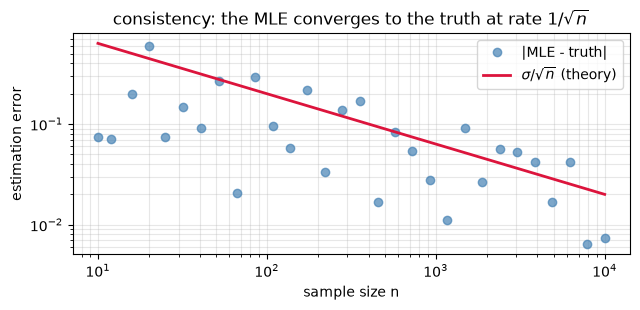

In [4]:
ns = np.unique(np.logspace(1, 4, 30).astype(int))
errs = []
for n in ns:
    x = rng.normal(truth_mu, truth_sd, n)
    errs.append(abs(x.mean() - truth_mu))

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.loglog(ns, errs, 'o', color='steelblue', alpha=0.7, label='|MLE - truth|')
ax.loglog(ns, truth_sd / np.sqrt(ns), 'crimson', lw=2, label=r'$\sigma/\sqrt{n}$ (theory)')
ax.set_xlabel('sample size n'); ax.set_ylabel('estimation error'); ax.legend(); ax.grid(alpha=0.3, which='both')
ax.set_title('consistency: the MLE converges to the truth at rate $1/\\sqrt{n}$')
plt.tight_layout(); plt.show()

## 4. Asymptotic normality: the sampling distribution

The second guarantee: for large $n$ the MLE is approximately Gaussian around the truth, $\hat\theta \approx \mathcal N(\theta,\ \mathcal I(\theta)^{-1}/n)$, where $\mathcal I$ is the Fisher information. This is why standard errors and Wald confidence intervals exist. We verify it empirically: refit on many independent samples and compare the histogram of $\hat\mu$ to the predicted Gaussian (for the mean, $\mathrm{Var}(\hat\mu)=\sigma^2/n$).


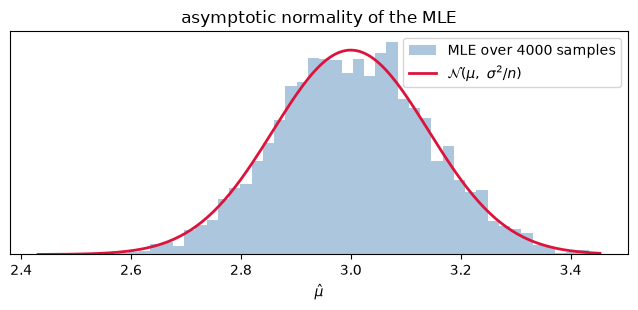

empirical sd(mu_hat)=0.1397   theory sigma/sqrt(n)=0.1414


In [5]:
n, reps = 200, 4000
mus = np.array([rng.normal(truth_mu, truth_sd, n).mean() for _ in range(reps)])
pred_sd = truth_sd / np.sqrt(n)

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.hist(mus, bins=50, density=True, alpha=0.45, color='steelblue', label='MLE over %d samples' % reps)
grid = np.linspace(mus.min(), mus.max(), 200)
ax.plot(grid, np.exp(-0.5 * ((grid - truth_mu) / pred_sd) ** 2) / (pred_sd * np.sqrt(2 * np.pi)),
        'crimson', lw=2, label=r'$\mathcal{N}(\mu,\ \sigma^2/n)$')
ax.set_title('asymptotic normality of the MLE'); ax.set_xlabel(r'$\hat\mu$'); ax.legend(); ax.set_yticks([])
plt.tight_layout(); plt.show()
print('empirical sd(mu_hat)=%.4f   theory sigma/sqrt(n)=%.4f' % (mus.std(), pred_sd))

## Never report an estimate without an interval

A point estimate is incomplete. The asymptotic theory above hands us standard errors for free: the MLE's covariance is $\mathcal I(\theta)^{-1}/n$, so for the Gaussian, $\mathrm{SE}(\hat\mu)=\hat\sigma/\sqrt n$ and $\mathrm{SE}(\hat\sigma^2)=\hat\sigma^2\sqrt{2/n}$. We compute these analytic (Wald) intervals and cross-check them against the bootstrap - they should agree when $n$ is large, and the bootstrap is the fallback when they don't (bootstrap_and_uncertainty).


In [6]:
# analytic (Fisher-information) standard errors for the Gaussian MLE
n = len(data); mu_hat = data.mean(); s2_hat = data.var()
se_mu = np.sqrt(s2_hat / n)                       # I(mu)^-1/n = sigma^2/n
se_s2 = s2_hat * np.sqrt(2.0 / n)                 # I(sigma^2)^-1/n = 2 sigma^4 / n
wald = lambda est, se: (est - 1.96 * se, est + 1.96 * se)

# bootstrap standard errors (no formula used)
B = 4000
boot = np.array([(lambda r: (r.mean(), r.var()))(data[rng.randint(0, n, n)]) for _ in range(B)])
print('parameter   MLE      Wald 95%% CI            bootstrap 95%% CI')
print('mu       %7.3f   [%6.3f, %6.3f]   [%6.3f, %6.3f]' % (
    mu_hat, *wald(mu_hat, se_mu), *np.percentile(boot[:, 0], [2.5, 97.5])))
print('sigma^2  %7.3f   [%6.3f, %6.3f]   [%6.3f, %6.3f]' % (
    s2_hat, *wald(s2_hat, se_s2), *np.percentile(boot[:, 1], [2.5, 97.5])))
print('\nanalytic SE(mu)=%.4f  bootstrap SE(mu)=%.4f  (agree at this n)' % (se_mu, boot[:, 0].std()))

parameter   MLE      Wald 95%% CI            bootstrap 95%% CI
mu         2.909   [ 2.787,  3.032]   [ 2.786,  3.032]
sigma^2    3.897   [ 3.555,  4.239]   [ 3.562,  4.219]

analytic SE(mu)=0.0624  bootstrap SE(mu)=0.0623  (agree at this n)


## Illustration: the non-regular uniform model

We verify the claim that for $X\sim\mathrm{Uniform}(0,\theta)$ the rescaled error
$n(\theta-\hat\theta)$ converges to an exponential, not a normal. A derivation makes the target exact:
$$P\big(n(\theta-\hat\theta) > t\big) = P\big(\max_i x_i < \theta - t/n\big)
   = \Big(1 - \tfrac{t}{n\theta}\Big)^n \xrightarrow[n\to\infty]{} e^{-t/\theta},$$
so the limit is $\mathrm{Exponential}$ with mean $\theta$. Compare its right-skewed shape to the
symmetric Gaussian limit of the sample mean.

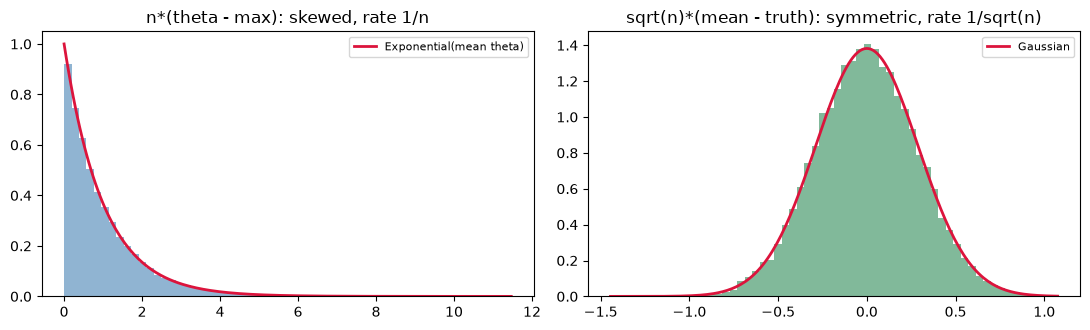

skewness of n*(theta-max) = 2.01 (exponential is 2.0, Gaussian is 0): not asymptotically normal
mean of n*(theta-max) = 0.998 (matches the exponential mean theta = 1.0)


In [7]:
from scipy import stats as _st
rng = np.random.RandomState(0)
theta = 1.0; n = 400; reps = 30000
err_max = np.array([n * (theta - np.max(rng.uniform(0, theta, n))) for _ in range(reps)])   # rate 1/n
err_mean = np.array([np.sqrt(n) * (rng.uniform(0, theta, n).mean() - theta / 2) for _ in range(reps)])
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].hist(err_max, bins=60, density=True, color='steelblue', alpha=0.6)
ts = np.linspace(0, err_max.max(), 200)
ax[0].plot(ts, _st.expon.pdf(ts, scale=theta), 'crimson', lw=2, label='Exponential(mean theta)')
ax[0].set_title('n*(theta - max): skewed, rate 1/n'); ax[0].legend(fontsize=8)
ax[1].hist(err_mean, bins=60, density=True, color='seagreen', alpha=0.6)
gs = np.linspace(err_mean.min(), err_mean.max(), 200)
ax[1].plot(gs, _st.norm.pdf(gs, 0, np.sqrt(theta ** 2 / 12)), 'crimson', lw=2, label='Gaussian')
ax[1].set_title('sqrt(n)*(mean - truth): symmetric, rate 1/sqrt(n)'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print('skewness of n*(theta-max) = %.2f (exponential is 2.0, Gaussian is 0): not asymptotically normal' %
      _st.skew(err_max))
print('mean of n*(theta-max) = %.3f (matches the exponential mean theta = %.1f)' % (err_max.mean(), theta))

## References

- Fisher, R. A. (1922). On the mathematical foundations of theoretical statistics (https://doi.org/10.1098/rsta.1922.0009). Phil. Trans. R. Soc. A 222, 309-368. - introduces sufficiency, efficiency, and maximum likelihood.
- van der Vaart, A. W. (1998). Asymptotic Statistics. Cambridge University Press. - consistency, asymptotic normality, the information bound.
- Lehmann, E. L. & Casella, G. (1998). Theory of Point Estimation, 2nd ed. Springer. - sufficiency, Rao-Blackwell, Cramér-Rao.
- Casella, G. & Berger, R. L. (2002). Statistical Inference, 2nd ed. Duxbury.
- Efron, B. & Hastie, T. (2016). Computer Age Statistical Inference (https://hastie.su.domains/CASI/). Cambridge University Press. - modern, computational perspective on the same foundations.


## Exercises and extensions

These are project-scale; each is an afternoon of work with a written conclusion and figures.

1. Asymptotic vs bootstrap standard errors on a two-parameter model. Fit a `GammaDistribution` by MLE. (a) Derive/compute the Fisher information matrix $\mathcal I(\theta)$ numerically (Hessian of the negative log-likelihood at $\hat\theta$) and form Wald standard errors $\sqrt{\mathrm{diag}(\mathcal I^{-1}/n)}$. (b) Compute bootstrap standard errors (resample, refit). (c) Run a coverage study: over 1000 simulated datasets at several $n$, report the empirical coverage of the 95% Wald and bootstrap intervals for both shape and rate. Where does the asymptotic interval under-cover, and why does the bootstrap do better at small $n$? Write up the comparison.
2. The Cramér-Rao bound, empirically. For the Gamma, compute the Cramér-Rao lower bound $\mathcal I(\theta)^{-1}/n$ and overlay it on the empirical variance of $\hat\theta$ across simulations as $n$ grows from 20 to 5000. Show the MLE is asymptotically efficient (variance → CRLB). Then construct a deliberately inefficient estimator (e.g. method-of-moments on a transformed statistic) and quantify its efficiency loss.
3. Rao-Blackwellization. Take a crude unbiased estimator of a Poisson functional (e.g. $\hat{P}(X=0)=\mathbb 1[X_1=0]$), Rao-Blackwellize it by conditioning on the sufficient statistic $\sum_i X_i$, derive the improved estimator in closed form, and demonstrate the variance reduction by simulation. Connect the result to why mixle's accumulators lose no information.
4. Distributed MLE by sufficient-statistic merging. Shard a large dataset across $k$ partitions, accumulate sufficient statistics independently on each (using the estimator's accumulator), merge them, and estimate; verify the result is bit-identical to a single-pass fit. Then benchmark wall-clock vs $k$ and discuss when the map-reduce form wins. This is the property that makes `optimize(backend=...)` scale - explain the link to the exponential-family form.
